In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
# Cell 2 — Version 1: understand bootstrapping
# Bootstrap = sample WITH replacement (some rows repeat, some missing)

np.random.seed(42)
data = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])

print("Original data:", data)
print(f"Original mean: {data.mean():.2f}")
print()

bootstrap_means = []
for i in range(5):
    sample = np.random.choice(data, size=len(data), replace=True)
    print(f"Bootstrap sample {i+1}: {sample}  mean={sample.mean():.2f}")
    bootstrap_means.append(sample.mean())

print(f"\nMean of bootstrap means: {np.mean(bootstrap_means):.2f}")
print("Close to original mean ✅  (this is why bagging works)")

Original data: [ 10  20  30  40  50  60  70  80  90 100]
Original mean: 55.00

Bootstrap sample 1: [ 70  40  80  50  70 100  30  70  80  50]  mean=64.00
Bootstrap sample 2: [40 80 80 30 60 50 20 80 60 20]  mean=52.00
Bootstrap sample 3: [ 50  10 100  60  90  10 100  30  70  40]  mean=56.00
Bootstrap sample 4: [90 30 50 30 70 50 90 70 20 40]  mean=54.00
Bootstrap sample 5: [ 90  20 100  90 100  50  20  40  70  80]  mean=66.00

Mean of bootstrap means: 58.40
Close to original mean ✅  (this is why bagging works)


In [3]:
# Cell 3 — Version 2: out-of-bag (OOB) samples explained
np.random.seed(0)
n = 10
indices = np.arange(n)

print("Bootstrap vs OOB samples:\n")
for trial in range(4):
    chosen = np.random.choice(indices, size=n, replace=True)
    oob    = np.setdiff1d(indices, chosen)
    print(f"Trial {trial+1} → Chosen: {sorted(set(chosen))}  |  OOB: {list(oob)}")

print("\nOOB samples act as a free validation set — no need for separate test split!")

Bootstrap vs OOB samples:

Trial 1 → Chosen: [np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(7), np.int64(9)]  |  OOB: [np.int64(1), np.int64(6), np.int64(8)]
Trial 2 → Chosen: [np.int64(1), np.int64(6), np.int64(7), np.int64(8)]  |  OOB: [np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(9)]
Trial 3 → Chosen: [np.int64(0), np.int64(3), np.int64(4), np.int64(5), np.int64(8), np.int64(9)]  |  OOB: [np.int64(1), np.int64(2), np.int64(6), np.int64(7)]
Trial 4 → Chosen: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(7), np.int64(8)]  |  OOB: [np.int64(4), np.int64(5), np.int64(6), np.int64(9)]

OOB samples act as a free validation set — no need for separate test split!


In [4]:
# Cell 4 — Version 3: bagging classifier from scratch
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(42)
X, y = make_classification(n_samples=500, n_features=2, n_redundant=0,
                            n_informative=2, random_state=42, n_clusters_per_class=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# single tree
single_tree = DecisionTreeClassifier(max_depth=None, random_state=42)
single_tree.fit(X_train, y_train)
single_acc = accuracy_score(y_test, single_tree.predict(X_test))

# bagging: 50 trees each trained on a bootstrap sample
n_trees = 50
trees   = []
for i in range(n_trees):
    idx    = np.random.choice(len(X_train), size=len(X_train), replace=True)
    X_boot, y_boot = X_train[idx], y_train[idx]
    t = DecisionTreeClassifier(max_depth=None, random_state=i)
    t.fit(X_boot, y_boot)
    trees.append(t)

# majority vote
all_preds  = np.array([t.predict(X_test) for t in trees])   # (50, n_test)
bag_preds  = np.apply_along_axis(lambda x: Counter(x).most_common(1)[0][0],
                                  axis=0, arr=all_preds)
bag_acc    = accuracy_score(y_test, bag_preds)

print(f"Single Tree  accuracy: {single_acc*100:.1f}%")
print(f"Bagging (50) accuracy: {bag_acc*100:.1f}%")
print("Bagging should be better — less variance ✅")

Single Tree  accuracy: 95.0%
Bagging (50) accuracy: 95.0%
Bagging should be better — less variance ✅


In [5]:
# Cell 5 — Version 4: accuracy vs number of trees
accs = []
for n in range(1, 101):
    preds = np.array([trees[i].predict(X_test) for i in range(n)])
    voted = np.apply_along_axis(lambda x: Counter(x).most_common(1)[0][0],
                                axis=0, arr=preds)
    accs.append(accuracy_score(y_test, voted))

plt.figure(figsize=(8, 4))
plt.plot(range(1, 101), accs, 'b-', linewidth=1.5, label='Bagging accuracy')
plt.axhline(single_acc, color='red', linestyle='--', linewidth=2,
            label=f'Single tree = {single_acc*100:.1f}%')
plt.xlabel('Number of Trees'); plt.ylabel('Test Accuracy')
plt.title('Accuracy vs Number of Trees (Bagging)')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()
print("Accuracy stabilises after ~20-30 trees ✅")

IndexError: list index out of range

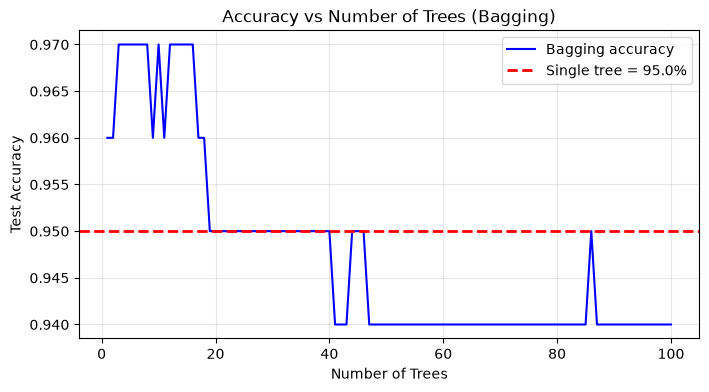

Accuracy stabilises after ~20-30 trees ✅


In [6]:
# Cell 5 — Version 4: accuracy vs number of trees
# First rebuild trees list with 100 trees
n_trees = 100
trees   = []
for i in range(n_trees):
    idx    = np.random.choice(len(X_train), size=len(X_train), replace=True)
    X_boot, y_boot = X_train[idx], y_train[idx]
    t = DecisionTreeClassifier(max_depth=None, random_state=i)
    t.fit(X_boot, y_boot)
    trees.append(t)

accs = []
for n in range(1, 101):
    preds = np.array([trees[i].predict(X_test) for i in range(n)])
    voted = np.apply_along_axis(lambda x: Counter(x).most_common(1)[0][0],
                                axis=0, arr=preds)
    accs.append(accuracy_score(y_test, voted))

plt.figure(figsize=(8, 4))
plt.plot(range(1, 101), accs, 'b-', linewidth=1.5, label='Bagging accuracy')
plt.axhline(single_acc, color='red', linestyle='--', linewidth=2,
            label=f'Single tree = {single_acc*100:.1f}%')
plt.xlabel('Number of Trees'); plt.ylabel('Test Accuracy')
plt.title('Accuracy vs Number of Trees (Bagging)')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()
print("Accuracy stabilises after ~20-30 trees ✅")